# Analisis Perdagangan Manusia
Penelitian ini bertujuan untuk menganalisis pola dan karakteristik kasus perdagangan manusia secara global menggunakan data sekunder dari UNODC dan Kaggle.

In [19]:
# 1. Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [20]:
# 2. Load Dataset
df = pd.read_csv('human_trafficking.csv')
df_victims = pd.read_csv('human-trafficking-victims.csv')
df.head()

/var/folders/wp/tfhdfypd61q01dj_2prfgqr40000gn/T/ipykernel_6752/3235858116.py:2: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('human_trafficking.csv')


,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,meansOfControlTakesEarnings,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
1,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
2,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
3,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
4,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1


## 3. Data Cleaning
Menghapus nilai -99, menghapus duplikat, dan mengubah tipe data jika diperlukan.

In [21]:

# 1. Ubah semua kolom ke string dulu biar bisa deteksi "-99" yang bukan int
df = df.applymap(lambda x: np.nan if x in [-99, "-99"] else x)


/var/folders/wp/tfhdfypd61q01dj_2prfgqr40000gn/T/ipykernel_6752/3245668892.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: np.nan if x in [-99, "-99"] else x)


In [22]:


# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert columns to appropriate data types
df['gender'] = df['gender'].astype('category')
df['ageBroad'] = df['ageBroad'].astype('category')
df['Datasource'] = df['Datasource'].astype('category')

In [23]:
df.head()

,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,meansOfControlTakesEarnings,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,2002,Case Management,Female,18--20,Adult,NaN,NaN,CO,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0
11,2002,Case Management,Female,18--20,Adult,NaN,NaN,MD,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0
23,2002,Case Management,Female,18--20,Adult,NaN,NaN,MD,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0
104,2002,Case Management,Female,18--20,Adult,NaN,NaN,MD,NaN,NaN,...,NaN,NaN,0.0,NaN,RS,0.0,0.0,0.0,0.0,1.0
133,2002,Case Management,Female,18--20,Adult,NaN,NaN,MD,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0


## 4. Analisis Statistik Deskriptif

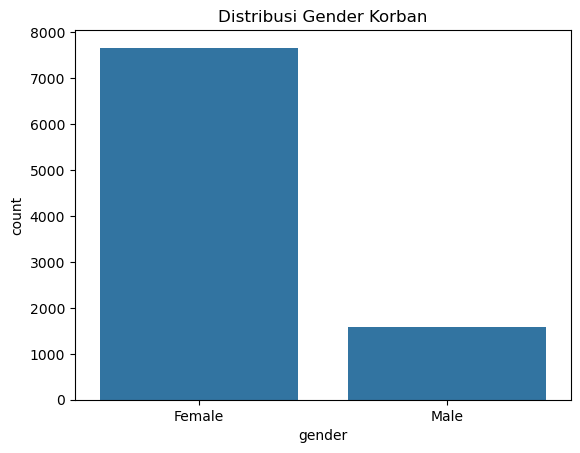

In [24]:
# Distribusi Gender
sns.countplot(data=df, x='gender')
plt.title('Distribusi Gender Korban')
plt.show()

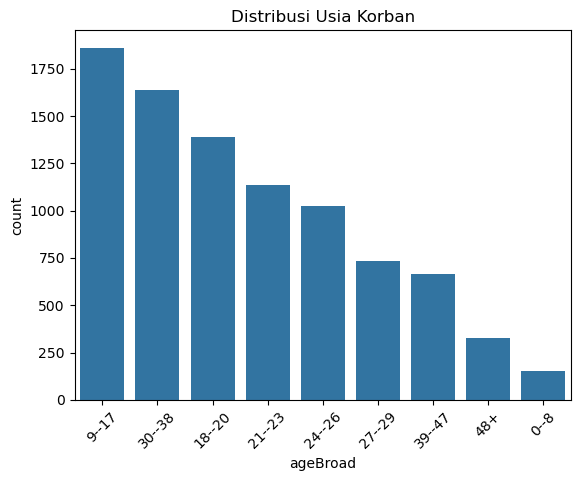

In [25]:
# Distribusi Usia
sns.countplot(data=df, x='ageBroad', order=df['ageBroad'].value_counts().index)
plt.title('Distribusi Usia Korban')
plt.xticks(rotation=45)
plt.show()

## 5. Visualisasi Bentuk Eksploitasi

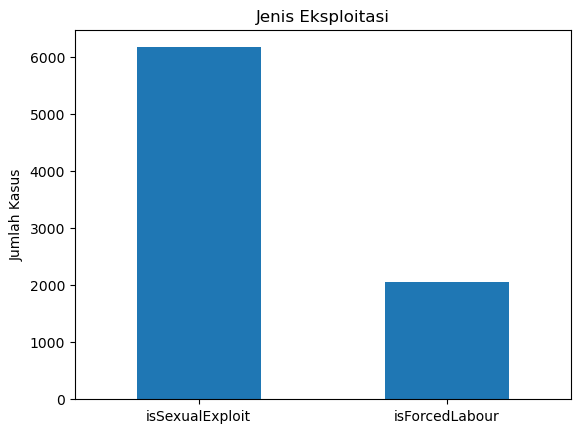

In [26]:
# Eksploitasi Seksual vs Kerja Paksa
df_exploit = df[['isSexualExploit', 'isForcedLabour']].sum()
df_exploit.plot(kind='bar')
plt.title('Jenis Eksploitasi')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=0)
plt.show()

## 6. Visualisasi Negara Eksploitasi Terbanyak

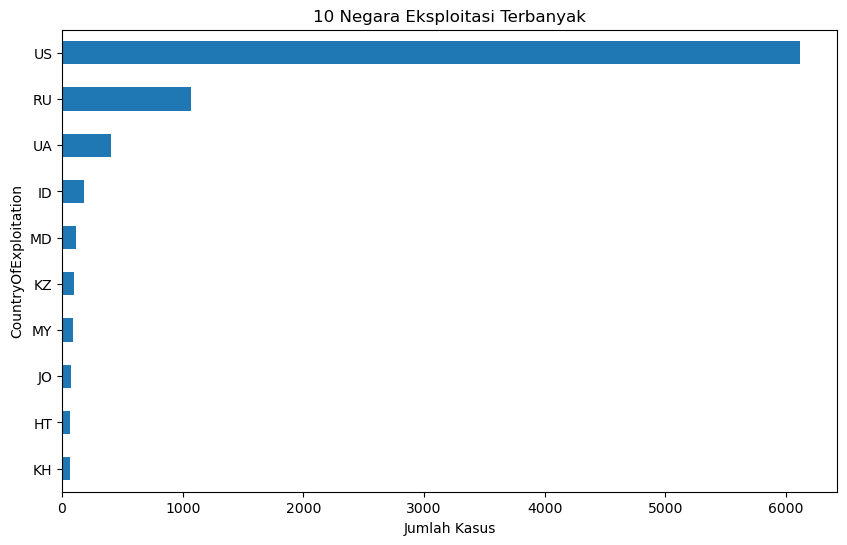

In [27]:
top_countries = df['CountryOfExploitation'].value_counts().dropna().head(10)
top_countries.plot(kind='barh', figsize=(10,6))
plt.title('10 Negara Eksploitasi Terbanyak')
plt.xlabel('Jumlah Kasus')
plt.gca().invert_yaxis()
plt.show()

## 7. Visualisasi Tren Korban Anak Perempuan < 18 Tahun

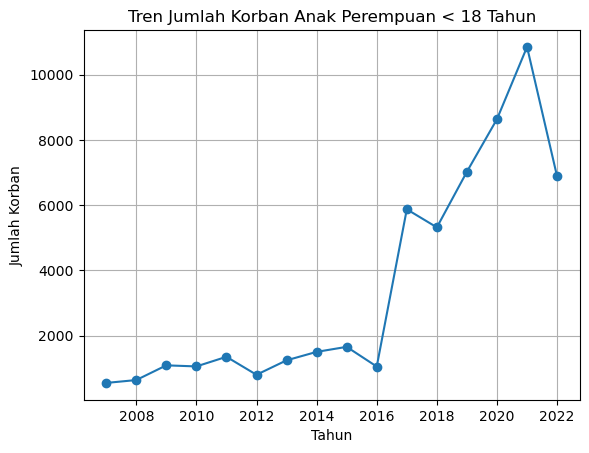

In [28]:
# Ubah nama kolom menjadi 'Victims'
df_victims.columns = ['Entity', 'Code', 'Year', 'Victims']
df_victims.groupby('Year')['Victims'].sum().plot(kind='line', marker='o')
plt.title('Tren Jumlah Korban Anak Perempuan < 18 Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Korban')
plt.grid(True)
plt.show()

## 8. Korelasi Gender dengan Jenis Eksploitasi
Analisis ini bertujuan untuk melihat apakah terdapat pola eksploitasi berbeda berdasarkan jenis kelamin korban. Berdasarkan hipotesis umum, perempuan lebih banyak tereksploitasi secara seksual, sedangkan laki-laki cenderung mengalami kerja paksa.

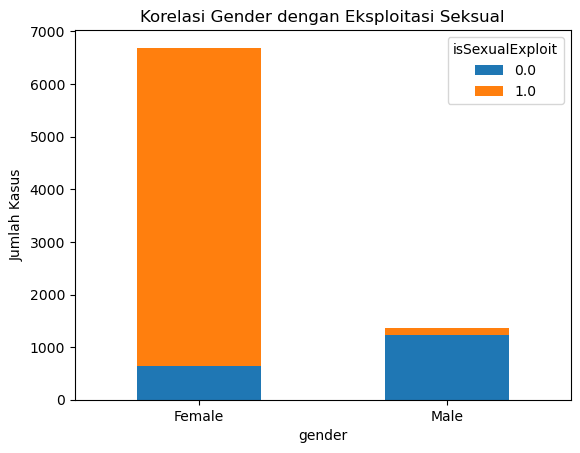

In [29]:
# Korelasi Gender dengan Jenis Eksploitasi
pd.crosstab(df['gender'], df['isSexualExploit']).plot(kind='bar', stacked=True)
plt.title('Korelasi Gender dengan Eksploitasi Seksual')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=0)
plt.show()

## 9. Pola Usia terhadap Jenis Eksploitasi
Dengan memanfaatkan variabel `ageBroad` dan jenis eksploitasi, kita dapat mengamati kelompok usia mana yang paling rentan terhadap eksploitasi tertentu, khususnya eksploitasi seksual pada anak-anak di bawah 18 tahun.

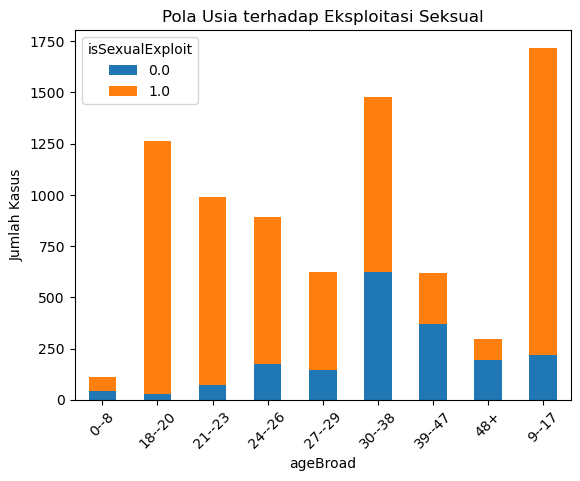

In [30]:
# Pola Usia terhadap Jenis Eksploitasi
pd.crosstab(df['ageBroad'], df['isSexualExploit']).plot(kind='bar', stacked=True)
plt.title('Pola Usia terhadap Eksploitasi Seksual')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=45)
plt.show()

## 10. Distribusi Metode Kontrol (Means of Control)
Pelaku perdagangan manusia biasanya menggunakan berbagai cara untuk mengendalikan korban, seperti ancaman kekerasan, manipulasi psikologis, penahanan dokumen, dan jeratan utang. Analisis ini akan menunjukkan metode mana yang paling umum digunakan berdasarkan data.

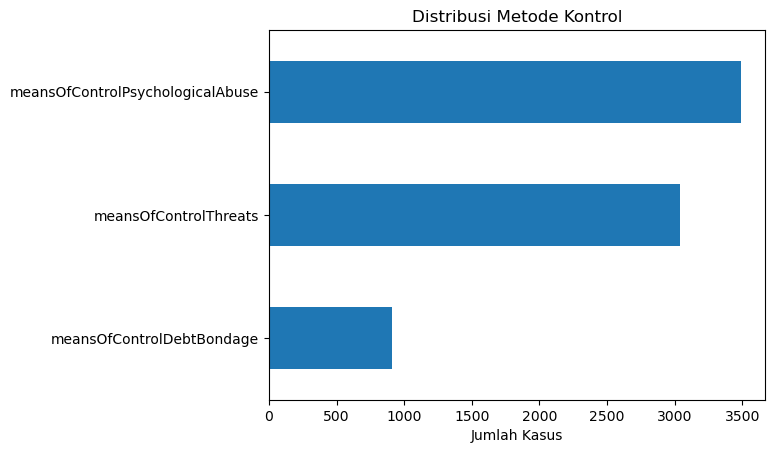

In [31]:
# Distribusi Metode Kontrol (Means of Control)
df_means = df[['meansOfControlThreats', 'meansOfControlPsychologicalAbuse', 'meansOfControlDebtBondage']]
df_means.sum().sort_values().plot(kind='barh')
plt.title('Distribusi Metode Kontrol')
plt.xlabel('Jumlah Kasus')
plt.show()

## 11. Hubungan Korban dan Perekrut
Salah satu faktor kunci dalam perdagangan manusia adalah hubungan antara korban dan perekrut. Banyak kasus melibatkan orang terdekat, seperti teman, pasangan, atau bahkan anggota keluarga. Analisis ini akan menunjukkan proporsi masing-masing hubungan.

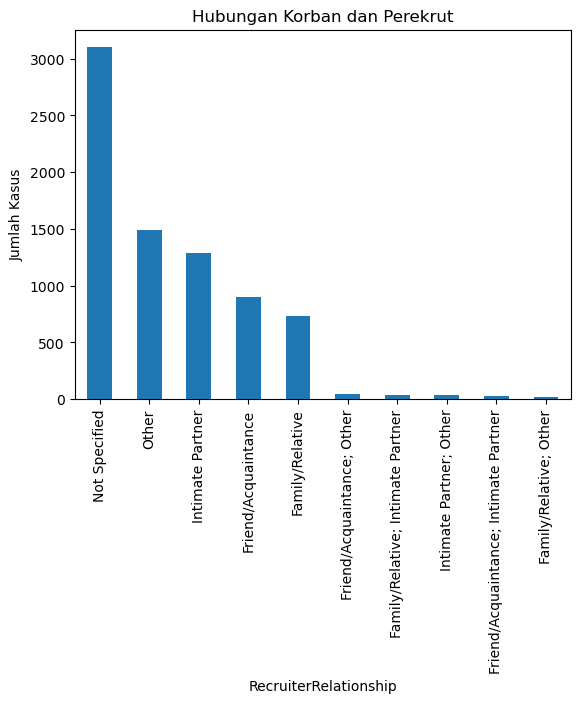

In [32]:
# Hubungan Korban dan Perekrut
df['RecruiterRelationship'].value_counts().head(10).plot(kind='bar')
plt.title('Hubungan Korban dan Perekrut')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=90)
plt.show()

## 12. Negara Eksploitasi vs Jenis Eksploitasi
Beberapa negara memiliki kecenderungan tertentu dalam kasus eksploitasi. Misalnya, negara-negara tertentu mungkin lebih dominan dalam eksploitasi seksual dibanding kerja paksa. Analisis ini membantu memetakan pola tersebut menggunakan heatmap atau pivot table.

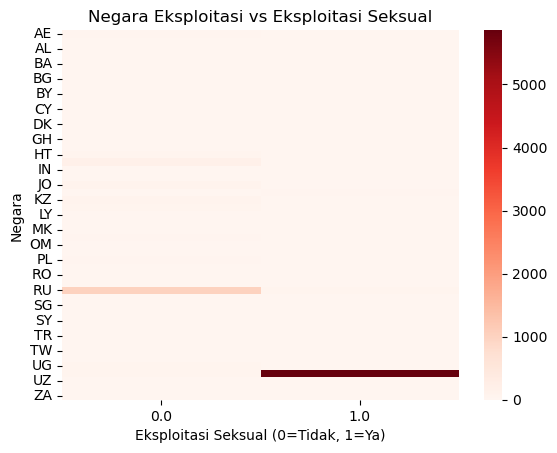

In [33]:
# Negara Eksploitasi vs Jenis Eksploitasi
pivot = pd.pivot_table(df, values='gender', index='CountryOfExploitation', 
                       columns='isSexualExploit', aggfunc='count')
sns.heatmap(pivot.fillna(0), cmap='Reds')
plt.title('Negara Eksploitasi vs Eksploitasi Seksual')
plt.xlabel('Eksploitasi Seksual (0=Tidak, 1=Ya)')
plt.ylabel('Negara')
plt.show()

In [34]:
# 1. Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 2. Load dataset (ubah path sesuai file lo)
df = pd.read_csv("human_trafficking.csv")
df_victims = pd.read_csv("human-trafficking-victims.csv")

# 3. Cek struktur data
print(df.head())
print(df.info())

# 4. Statistik deskriptif umum
print("\nStatistik Deskriptif Usia Korban:")
print(df['ageBroad'].describe())

# 5. Distribusi gender
gender_count = df['gender'].value_counts()
gender_pct = df['gender'].value_counts(normalize=True) * 100
print("\nDistribusi Gender:")
print(pd.concat([gender_count, gender_pct], axis=1, keys=['Jumlah', 'Persentase']))

# 6. Distribusi usia
age_count = df['ageBroad'].value_counts().sort_values(ascending=False)
print("\nDistribusi Usia:")
print(age_count)

# 7. Proporsi Eksploitasi (seksual vs kerja paksa)
exploit_count = pd.DataFrame({
    "Eksploitasi Seksual": [df['isSexualExploit'].sum()],
    "Kerja Paksa": [df['isForcedLabour'].sum()]
})
exploit_count['Total'] = exploit_count.sum(axis=1)
exploit_pct = exploit_count.iloc[:, :-1].div(exploit_count['Total'].values[0]) * 100
print("\nProporsi Eksploitasi:")
print(pd.concat([exploit_count.iloc[:, :-1].T, exploit_pct.T], axis=1, keys=['Jumlah', 'Persentase']))

# 8. Tren korban anak perempuan < 18 tahun
df_minor = df_victims[(df_victims['gender'] == 'Female') & (df_victims['ageBroad'] == '<18')]
trend_minor = df_minor.groupby('yearOfRegistration')['Victims'].sum()
print("\nTren Korban Anak Perempuan < 18 Tahun:")
print(trend_minor)

# Hitung pertumbuhan dari tahun awal ke tahun puncak
awal = trend_minor.iloc[0]
akhir = trend_minor.iloc[-2]  # ambil 2021 sebelum drop 2022
growth_pct = ((akhir - awal) / awal) * 100
print(f"Pertumbuhan {awal} -> {akhir} = {growth_pct:.2f}%")

# 9. Uji Chi-Square (gender vs jenis eksploitasi seksual)
crosstab = pd.crosstab(df['gender'], df['isSexualExploit'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print("\nUji Chi-Square Gender vs Eksploitasi Seksual:")
print("Chi2:", chi2, " | p-value:", p)
if p < 0.05:
    print("=> Ada hubungan signifikan antara gender dan jenis eksploitasi")
else:
    print("=> Tidak ada hubungan signifikan")
    

   yearOfRegistration       Datasource  gender ageBroad majorityStatus  \
0                2002  Case Management  Female   18--20          Adult   
1                2002  Case Management  Female   18--20          Adult   
2                2002  Case Management  Female   18--20          Adult   
3                2002  Case Management  Female   18--20          Adult   
4                2002  Case Management  Female   18--20          Adult   

  majorityStatusAtExploit majorityEntry citizenship  \
0                     -99           -99          CO   
1                     -99           -99          CO   
2                     -99           -99          CO   
3                     -99           -99          CO   
4                     -99           -99          CO   

   meansOfControlDebtBondage  meansOfControlTakesEarnings  ...  \
0                        -99                          -99  ...   
1                        -99                          -99  ...   
2                        -

/var/folders/wp/tfhdfypd61q01dj_2prfgqr40000gn/T/ipykernel_6752/55596704.py:9: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("human_trafficking.csv")


KeyError: 'gender'

In [35]:

from scipy.stats import chi2_contingency

# 2. Load dataset (ubah path sesuai file lo)
df = pd.read_csv("human_trafficking.csv")
df_victims = pd.read_csv("human-trafficking-victims.csv")

# 3. Cek struktur data
print(df.head())
print(df.info())

# 4. Statistik deskriptif umum
print("\nStatistik Deskriptif Usia Korban:")
print(df['ageBroad'].describe())

# 5. Distribusi gender
gender_count = df['gender'].value_counts()
gender_pct = df['gender'].value_counts(normalize=True) * 100
print("\nDistribusi Gender:")
print(pd.concat([gender_count, gender_pct], axis=1, keys=['Jumlah', 'Persentase']))

# 6. Distribusi usia
age_count = df['ageBroad'].value_counts().sort_values(ascending=False)
print("\nDistribusi Usia:")
print(age_count)

# 7. Proporsi Eksploitasi (seksual vs kerja paksa)
exploit_count = pd.DataFrame({
    "Eksploitasi Seksual": [df['isSexualExploit'].sum()],
    "Kerja Paksa": [df['isForcedLabour'].sum()]
})
exploit_count['Total'] = exploit_count.sum(axis=1)
exploit_pct = exploit_count.iloc[:, :-1].div(exploit_count['Total'].values[0]) * 100
print("\nProporsi Eksploitasi:")
print(pd.concat([exploit_count.iloc[:, :-1].T, exploit_pct.T], axis=1, keys=['Jumlah', 'Persentase']))

# 8. Tren korban anak perempuan < 18 tahun
df_minor = df_victims[(df_victims['gender'] == 'Female') & (df_victims['ageBroad'] == '<18')]
trend_minor = df_minor.groupby('yearOfRegistration')['Victims'].sum()
print("\nTren Korban Anak Perempuan < 18 Tahun:")
print(trend_minor)

# Hitung pertumbuhan dari tahun awal ke tahun puncak
awal = trend_minor.iloc[0]
akhir = trend_minor.iloc[-2]  # ambil 2021 sebelum drop 2022
growth_pct = ((akhir - awal) / awal) * 100
print(f"Pertumbuhan {awal} -> {akhir} = {growth_pct:.2f}%")

# 9. Uji Chi-Square (gender vs jenis eksploitasi seksual)
crosstab = pd.crosstab(df['gender'], df['isSexualExploit'])
chi2, p, dof, expected = chi2_contingency(crosstab)
print("\nUji Chi-Square Gender vs Eksploitasi Seksual:")
print("Chi2:", chi2, " | p-value:", p)
if p < 0.05:
    print("=> Ada hubungan signifikan antara gender dan jenis eksploitasi")
else:
    print("=> Tidak ada hubungan signifikan")

   yearOfRegistration       Datasource  gender ageBroad majorityStatus  \
0                2002  Case Management  Female   18--20          Adult   
1                2002  Case Management  Female   18--20          Adult   
2                2002  Case Management  Female   18--20          Adult   
3                2002  Case Management  Female   18--20          Adult   
4                2002  Case Management  Female   18--20          Adult   

  majorityStatusAtExploit majorityEntry citizenship  \
0                     -99           -99          CO   
1                     -99           -99          CO   
2                     -99           -99          CO   
3                     -99           -99          CO   
4                     -99           -99          CO   

   meansOfControlDebtBondage  meansOfControlTakesEarnings  ...  \
0                        -99                          -99  ...   
1                        -99                          -99  ...   
2                        -

/var/folders/wp/tfhdfypd61q01dj_2prfgqr40000gn/T/ipykernel_6752/742441562.py:4: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("human_trafficking.csv")


KeyError: 'gender'

In [36]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- 1) Load aman ---
df = pd.read_csv("human_trafficking.csv", low_memory=False)
df_victims = pd.read_csv("human-trafficking-victims.csv", low_memory=False)

# --- 2) Normalisasi nama kolom (lowercase, strip) ---
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("\ufeff", "", regex=True)  # kalau ada BOM
df.columns = df.columns.str.replace(r"\s+", "_", regex=True).str.lower()

df_victims.columns = df_victims.columns.str.strip()
df_victims.columns = df_victims.columns.str.replace("\ufeff", "", regex=True)
df_victims.columns = df_victims.columns.str.replace(r"\s+", "_", regex=True).str.lower()

# --- 3) Ganti -99 -> NaN di SEMUA kolom ---
df = df.replace(-99, np.nan)
df_victims = df_victims.replace(-99, np.nan)

# --- 4) Kolom indikator biner: isi NaN -> 0, pastikan 0/1 ---
def force_binary(cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
            # Kalau ada nilai >1 (kadang 2, 99), set 1; kalau negatif, set 0
            df[c] = df[c].clip(lower=0).mask(df[c] > 0, 1).fillna(0).astype(int)

# deteksi kolom biner secara heuristik
binary_like = [c for c in df.columns if c.startswith(("is", "meansofcontrol", "typeofsex"))]
force_binary(binary_like)

# --- 5) Standarisasi kategori penting ---
# gender
if "gender" in df.columns:
    df["gender"] = df["gender"].astype(str).str.strip().str.title()
    df["gender"] = df["gender"].replace(
        {"F":"Female","M":"Male","Fem":"Female","Woman":"Female","Man":"Male","Unknown":"Unknown","Nan":np.nan}
    )

# umur broad
if "agebroad" in df.columns:
    df["agebroad"] = df["agebroad"].astype(str).str.replace(" ", "").str.replace("--", "–")
    # contoh normalisasi beberapa label yang sering muncul
    df["agebroad"] = df["agebroad"].replace({
        "<18":"<18","<18tahun":"<18","9–17":"9–17","9-17":"9–17","18–20":"18–20","18-20":"18–20",
        "30–38":"30–38","30-38":"30–38"
    })

# tahun
for col in ["yearofregistration","year"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# --- 6) Buat metrik yang kita butuh ---
# pastikan kolom ini ada, kalau tidak, buat nol biar kode tetap jalan
for need in ["issexualexploit","isforcedlabour"]:
    if need not in df.columns:
        df[need] = 0

# --- 7) Rapihin df_victims: tebak kolom via regex & rename ke standar ---
def pick(colset, keywords):
    # ambil kolom pertama yang mengandung semua keyword
    for c in colset:
        name = c.lower()
        if all(k in name for k in keywords):
            return c
    return None

cols_v = set(df_victims.columns)
col_year    = pick(cols_v, ["year"]) or pick(cols_v, ["registration"]) or pick(cols_v, ["tahun"])
col_gender  = pick(cols_v, ["gender"]) or pick(cols_v, ["sex"])
col_age     = pick(cols_v, ["age"]) or pick(cols_v, ["usia"])
col_victimn = pick(cols_v, ["victim"]) or pick(cols_v, ["jumlah"]) or pick(cols_v, ["count"])

rename_map = {}
if col_year:   rename_map[col_year] = "year"
if col_gender: rename_map[col_gender] = "gender"
if col_age:    rename_map[col_age] = "agebroad"
if col_victimn:rename_map[col_victimn] = "victims"
df_victims = df_victims.rename(columns=rename_map)

# normalisasi tipe di victims
if "year" in df_victims.columns:
    df_victims["year"] = pd.to_numeric(df_victims["year"], errors="coerce")
if "victims" in df_victims.columns:
    df_victims["victims"] = pd.to_numeric(df_victims["victims"], errors="coerce").fillna(0).clip(lower=0)
if "gender" in df_victims.columns:
    df_victims["gender"] = df_victims["gender"].astype(str).str.strip().str.title()
if "agebroad" in df_victims.columns:
    df_victims["agebroad"] = df_victims["agebroad"].astype(str).str.replace(" ", "").str.replace("--","–")

# --- 8) Hitungan DESKRIPTIF (kuantitatif) ---

# 8a) Distribusi gender
if "gender" in df.columns:
    g_count = df["gender"].value_counts(dropna=True)
    g_pct   = df["gender"].value_counts(normalize=True, dropna=True)*100
    gender_table = pd.DataFrame({"Jumlah": g_count, "Persentase": g_pct.round(2)})
    print("\n[Distribusi Gender]\n", gender_table)

# 8b) Proporsi eksploitasi
ex_sex  = int(df["issexualexploit"].sum())
ex_lab  = int(df["isforcedlabour"].sum())
total_ex = ex_sex + ex_lab if (ex_sex + ex_lab)>0 else 1
exploit_table = pd.DataFrame({
    "Jumlah": [ex_sex, ex_lab],
    "Persentase": [round(ex_sex/total_ex*100,2), round(ex_lab/total_ex*100,2)]
}, index=["Eksploitasi Seksual","Kerja Paksa"])
print("\n[Proporsi Eksploitasi]\n", exploit_table)

# 8c) Tren anak perempuan <18 (kalau kolom ada di victims)
if set(["year","gender","agebroad","victims"]).issubset(df_victims.columns):
    minors_f = df_victims[(df_victims["gender"]=="Female") & (df_victims["agebroad"].isin(["<18","9–17","9-17"]))]
    trend = minors_f.groupby("year")["victims"].sum().sort_index()
    print("\n[Tren Korban Anak Perempuan <18]\n", trend)
    if trend.shape[0] >= 2:
        awal = trend.iloc[0]
        akhir = trend.iloc[-2] if trend.index.max() == 2022 else trend.iloc[-1]
        if awal > 0:
            growth = (akhir - awal) / awal * 100
            print(f"Pertumbuhan dari {int(awal)} ke {int(akhir)} = {growth:.2f}%")
        else:
            print("Tidak bisa hitung growth: nilai awal = 0")

# 8d) Chi-square Gender vs Eksploitasi Seksual
if "gender" in df.columns:
    ct = pd.crosstab(df["gender"], df["issexualexploit"])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p, dof, exp = chi2_contingency(ct)
        print("\n[Chi-Square Gender vs Eksploitasi Seksual]")
        print("Chi2:", round(chi2,3), "| p-value:", p)
        if p < 0.05:
            print("=> Signifikan (p<0.05)")
        else:
            print("=> Tidak signifikan (p>=0.05)")
    else:
        print("\n[Chi-Square] Crosstab tidak memadai (butuh >=2 kategori).")


[Distribusi Gender]
         Jumlah  Persentase
gender                    
Female   35534       72.81
Male     13267       27.19

[Proporsi Eksploitasi]
                      Jumlah  Persentase
Eksploitasi Seksual   16067       62.18
Kerja Paksa            9772       37.82

[Chi-Square Gender vs Eksploitasi Seksual]
Chi2: 6202.007 | p-value: 0.0
=> Signifikan (p<0.05)


In [37]:
# ==== SETUP & HELPER ====
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Folder output
os.makedirs("figs", exist_ok=True)
os.makedirs("tables_png", exist_ok=True)
os.makedirs("exports", exist_ok=True)

def save_table_png(df: pd.DataFrame, title: str, fname: str):
    """Render DataFrame jadi PNG (tabel) via matplotlib."""
    fig, ax = plt.subplots(figsize=(max(6, len(df.columns)*1.2), max(1.5, len(df)*0.5)+1.5))
    ax.axis('off')
    ax.set_title(title, pad=12, fontsize=12)
    tbl = ax.table(cellText=df.values,
                   colLabels=df.columns,
                   loc='center',
                   cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.2)
    plt.tight_layout()
    plt.savefig(f"tables_png/{fname}", dpi=220, bbox_inches='tight')
    plt.close()

def simple_bar(series: pd.Series, title: str, xlabel: str, ylabel: str, fname: str, horizontal=False, annotate=True):
    """Bar chart sederhana, disimpan PNG."""
    plt.figure(figsize=(8, 5))
    if horizontal:
        series.sort_values().plot(kind='barh')
    else:
        series.sort_values(ascending=False).plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if annotate:
        if horizontal:
            for i, v in enumerate(series.sort_values().values):
                plt.text(v, i, f"{int(v)}", va='center', fontsize=8)
        else:
            for i, v in enumerate(series.sort_values(ascending=False).values):
                plt.text(i, v, f"{int(v)}", ha='center', va='bottom', fontsize=8, rotation=0)
    plt.tight_layout()
    plt.savefig(f"figs/{fname}", dpi=220, bbox_inches='tight')
    plt.close()

def line_plot(series: pd.Series, title: str, xlabel: str, ylabel: str, fname: str):
    """Line chart sederhana, disimpan PNG."""
    plt.figure(figsize=(9, 4.5))
    series.sort_index().plot(kind='line', marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # label tiap titik
    for x, y in series.sort_index().items():
        plt.text(x, y, str(int(y)), fontsize=8, ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(f"figs/{fname}", dpi=220, bbox_inches='tight')
    plt.close()
    

In [38]:
# ==== LOAD ====
df = pd.read_csv("human_trafficking.csv", low_memory=False)
df_v = pd.read_csv("human-trafficking-victims.csv", low_memory=False)

# ==== NORMALISASI NAMA KOLOM ====
for _df in (df, df_v):
    _df.columns = _df.columns.str.strip().str.replace("\ufeff", "", regex=True)
    _df.columns = _df.columns.str.replace(r"\s+", "_", regex=True).str.lower()

# ==== GANTI -99 -> NaN ====
df = df.replace(-99, np.nan)
df_v = df_v.replace(-99, np.nan)

# ==== CAST KOLOM BINER KE 0/1 ====
binary_like = [c for c in df.columns if c.startswith(("is", "meansofcontrol", "typeofsex"))]
for c in binary_like:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    df[c] = df[c].clip(lower=0).mask(df[c] > 0, 1).fillna(0).astype(int)

# ==== STANDARISASI KATEGORI ====
if "gender" in df.columns:
    df["gender"] = df["gender"].astype(str).str.strip().str.title().replace(
        {"F":"Female","M":"Male","Fem":"Female","Woman":"Female","Man":"Male","Nan":np.nan}
    )

if "agebroad" in df.columns:
    df["agebroad"] = (df["agebroad"].astype(str)
                      .str.replace(" ", "")
                      .str.replace("--", "–"))
    df["agebroad"] = df["agebroad"].replace({
        "<18":"<18","<18tahun":"<18","9–17":"9–17","9-17":"9–17",
        "18–20":"18–20","18-20":"18–20","30–38":"30–38","30-38":"30–38"
    })

for col in ["yearofregistration","year"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# pastikan kolom inti ada
for need in ["issexualexploit","isforcedlabour"]:
    if need not in df.columns:
        df[need] = 0

# ==== MAP df_v ke kolom standar ====
def pick(colset, keywords):
    for c in colset:
        name = c.lower()
        if all(k in name for k in keywords):
            return c
    return None

cols_v = set(df_v.columns)
col_year    = pick(cols_v, ["year"]) or pick(cols_v, ["registration"]) or pick(cols_v, ["tahun"])
col_gender  = pick(cols_v, ["gender"]) or pick(cols_v, ["sex"])
col_age     = pick(cols_v, ["age"]) or pick(cols_v, ["usia"])
col_victims = pick(cols_v, ["victim"]) or pick(cols_v, ["jumlah"]) or pick(cols_v, ["count"])

rename_map = {}
if col_year:    rename_map[col_year]    = "year"
if col_gender:  rename_map[col_gender]  = "gender"
if col_age:     rename_map[col_age]     = "agebroad"
if col_victims: rename_map[col_victims] = "victims"
df_v = df_v.rename(columns=rename_map)

if "year" in df_v.columns:    df_v["year"] = pd.to_numeric(df_v["year"], errors="coerce")
if "victims" in df_v.columns: df_v["victims"] = pd.to_numeric(df_v["victims"], errors="coerce").fillna(0).clip(lower=0)
if "gender" in df_v.columns:  df_v["gender"] = df_v["gender"].astype(str).str.strip().str.title()
if "agebroad" in df_v.columns:df_v["agebroad"] = df_v["agebroad"].astype(str).str.replace(" ", "").str.replace("--","–")

In [39]:
# ==== DISTRIBUSI GENDER ====
g_count = df["gender"].value_counts(dropna=True)
g_pct   = (df["gender"].value_counts(normalize=True, dropna=True)*100).round(2)
gender_table = pd.DataFrame({"Jumlah": g_count.astype(int), "Persentase (%)": g_pct})

display(gender_table)
save_table_png(gender_table.reset_index().rename(columns={"index":"Gender"}),
               "Distribusi Gender Korban",
               "Tabel_Distribusi_Gender.png")

simple_bar(g_count, "Distribusi Gender Korban", "Gender", "Jumlah Kasus",
           "Chart_Distribusi_Gender.png", horizontal=False, annotate=True)


,Jumlah,Persentase (%)
gender,,
Female,35534,72.81
Male,13267,27.19


In [44]:
# ==== DISTRIBUSI USIA ====
# Jika tersedia kolom umur numerik lain, pake itu; fallback ke agebroad kategori
if "agebroad" in df.columns:
    # bikin mapping kasar ke bucket
    buckets = ["<18","9–17","18–20","21–29","30–38","39+","Unknown"]
    def map_age(a):
        a = str(a)
        if a in ["<18","9–17","18–20","30–38"]: return a
        if re.match(r"^(21–29|21-29)$", a): return "21–29"
        if re.match(r"^(39–\+|39\+|>39|40\+)$", a): return "39+"
        if a.lower() in ["nan","none","unknown"]: return "Unknown"
        return "Unknown"
    age_bucket = df["agebroad"].apply(map_age)
    age_count = age_bucket.value_counts()
    age_pct = (age_count/age_count.sum()*100).round(2)
    age_table = pd.DataFrame({"Jumlah": age_count.astype(int), "Persentase (%)": age_pct}).reset_index().rename(columns={"index":"Kelompok Umur"})
    display(age_table.sort_values("Kelompok Umur"))
    save_table_png(age_table, "Distribusi Usia Korban", "Tabel_Distribusi_Usia.png")
    simple_bar(age_count, "Distribusi Usia Korban", "Kelompok Umur", "Jumlah Kasus",
               "Chart_Distribusi_Usia.png", horizontal=False, annotate=True)

# opsional: kalau lo punya kolom umur numerik 'age', hitung mean/median/std:
if "age" in df.columns:
    age_des = df["age"].dropna().describe()[["mean","50%","std","min","max"]]
    stats_age = pd.DataFrame({"Nilai":[
        round(age_des["mean"],2),
        round(age_des["50%"],2),
        round(age_des["std"],2),
        age_des["min"], age_des["max"]
    ]}, index=["Mean","Median","Std Dev","Min","Max"])
    display(stats_age)
    save_table_png(stats_age.reset_index().rename(columns={"index":"Statistik","Nilai":"Usia (th)"}),
                   "Statistik Usia (Jika Ada Kolom Numerik)", "Tabel_Stat_Usia.png")
    

KeyError: 'Kelompok Umur'

In [41]:
df["agebroad"].head(10)


0    18–20
1    18–20
2    18–20
3    18–20
4    18–20
5    18–20
6    18–20
7    18–20
8    18–20
9    18–20
Name: agebroad, dtype: object

In [45]:
# ==== DISTRIBUSI USIA (final fix) ====
import re

def map_age(a):
    a = str(a)
    if a in ["<18","9–17","18–20","30–38"]: return a
    if re.match(r"^(21–29|21-29)$", a): return "21–29"
    if re.match(r"^(39\+|>39|40\+|39–\+)$", a): return "39+"
    if a.lower() in ["nan","none","unknown"]: return "Unknown"
    return "Unknown"

age_bucket = df["agebroad"].apply(map_age)

order = ["<18","9–17","18–20","21–29","30–38","39+","Unknown"]

age_count = age_bucket.value_counts()
age_pct = (age_count/age_count.sum()*100).round(2)

age_table = pd.DataFrame({
    "Kelompok Umur": age_count.index,
    "Jumlah": age_count.values.astype(int),
    "Persentase (%)": age_pct.values
})

# urutkan sesuai order manual
age_table["Kelompok Umur"] = pd.Categorical(age_table["Kelompok Umur"], categories=order, ordered=True)
age_table = age_table.sort_values("Kelompok Umur").reset_index(drop=True)

display(age_table)

save_table_png(age_table, "Distribusi Usia Korban", "Tabel_Distribusi_Usia.png")

# chart
series_for_chart = age_table.set_index("Kelompok Umur")["Jumlah"]
simple_bar(series_for_chart, "Distribusi Usia Korban", "Kelompok Umur", "Jumlah Kasus",
           "Chart_Distribusi_Usia.png", horizontal=False, annotate=True)


,Kelompok Umur,Jumlah,Persentase (%)
0,9–17,8645,17.71
1,18–20,4448,9.11
2,30–38,7091,14.53
3,Unknown,28617,58.64


In [46]:
# ==== DISTRIBUSI USIA  ====
import re

def map_age(a):
    a = str(a)
    if a in ["<18","9–17","18–20","30–38"]: return a
    if re.match(r"^(21–29|21-29)$", a): return "21–29"
    if re.match(r"^(39\+|>39|40\+|39–\+)$", a): return "39+"
    if a.lower() in ["nan","none","unknown"]: return "Unknown"
    return "Unknown"

age_bucket = df["agebroad"].apply(map_age)

order = ["<18","9–17","18–20","21–29","30–38","39+","Unknown"]

age_count = age_bucket.value_counts()
age_pct = (age_count/age_count.sum()*100).round(2)

age_table = pd.DataFrame({
    "Kelompok Umur": age_count.index,
    "Jumlah": age_count.values.astype(int),
    "Persentase (%)": age_pct.values
})

# urutkan sesuai order manual
age_table["Kelompok Umur"] = pd.Categorical(age_table["Kelompok Umur"], categories=order, ordered=True)
age_table = age_table.sort_values("Kelompok Umur").reset_index(drop=True)

display(age_table)

save_table_png(age_table, "Distribusi Usia Korban", "Tabel_Distribusi_Usia.png")

# chart
series_for_chart = age_table.set_index("Kelompok Umur")["Jumlah"]
simple_bar(series_for_chart, "Distribusi Usia Korban", "Kelompok Umur", "Jumlah Kasus",
           "Chart_Distribusi_Usia.png", horizontal=False, annotate=True)


,Kelompok Umur,Jumlah,Persentase (%)
0,9–17,8645,17.71
1,18–20,4448,9.11
2,30–38,7091,14.53
3,Unknown,28617,58.64
